# Setup

Imports, reproducibility seeds, and device selection. The dataset is loaded directly from HuggingFace (`ADS599-Capstone/confidence_delta_data`) — a pre-processed version of the 40% inference split from `lstm_one_hot_modeling.ipynb` with per-timestep P(ICU) confidence scores appended. Loading from HF avoids re-running the full LSTM preprocessing pipeline in this notebook.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import copy
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, BatchSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, recall_score, brier_score_loss, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option('display.max_columns', 150)

torch.manual_seed(10)
np.random.seed(10)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cpu device


In [2]:
data_repo = 'ADS599-Capstone/confidence_delta_data'
df = load_dataset(path=data_repo, split='rl_train').to_pandas()
print(f'Loaded: {df.shape}')
print(df[['ed_stay_id', 'step_idx', 'p_icu', 'terminal_event', 'terminal_code']].head())
print(f"\nUnique stays: {df['ed_stay_id'].nunique():,}")
print(f"Terminal distribution:")
print(df.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())

Loaded: (448737, 233)
   ed_stay_id  step_idx     p_icu  terminal_event  terminal_code
0    30000177         0  0.840725  DISCHARGE_WARD              0
1    30000177         1  0.997999  DISCHARGE_WARD              0
2    30000177         2  0.999968  DISCHARGE_WARD              0
3    30000177         3  0.999974  DISCHARGE_WARD              0
4    30000177         4  0.999271  DISCHARGE_WARD              0

Unique stays: 33,684
Terminal distribution:
terminal_event
DISCHARGE_ED      15211
DISCHARGE_WARD    11175
ICU                7298
Name: count, dtype: int64


# State Columns

Define which columns constitute the agent's observable state at each timestep.

**Excluded from state:**
- `ed_stay_id`, `terminal_code`, `terminal_event` — identifiers and labels, not features
- `step_idx`, `p_icu`, `delta_p_icu` — `p_icu` is used in the reward function only; the agent does not see the LSTM confidence directly. It learns to act on the raw ED features.
- `in_ed`, `in_ward` — these columns were not used to generate the per-timestep LSTM predictions and would introduce inconsistency between training and inference
- `admission_type_*` OHE columns — not part of the LSTM feature set
- `time` — raw datetime, not a model feature
- Action columns (`observe`, `vitals_checked`, etc.) — these are actions taken, not patient state features

In [3]:
action_names = [
    'observe', 'vitals_checked', 'labs_ordered', 'micro_ordered',
    'ecg_ordered', 'rad_ordered', 'dispense_meds', 'discharge', 'transfer_icu'
]

exclude = set(
    ['ed_stay_id', 'terminal_code', 'terminal_event',
     'step_idx', 'p_icu', 'delta_p_icu',
     'in_ed', 'in_ward', 'time',
     'terminal_state', 'time_steps', 'action_taken', 'reward', 'admission_missing']
    + action_names
    + [c for c in df.columns if c.startswith('admission_type_')]
)

state = [c for c in df.columns if c not in exclude]
print(f'State features: {len(state)}')
print(state[:10])

State features: 216
['Other', 'Analgesic - Opioid/NSAID', 'Antiemetic', 'Analgesic - Acetaminophen', 'Antibiotic', 'Benzodiazepine - Sedative/Anxiolytic', 'Analgesic - NSAID', 'Bronchodilator', 'Antiplatelet', 'GI - Acid Suppression']


# Terminal Row and Action Encoding

Mark the last timestep of each ED stay as the terminal state — this is the point at which the provider made their disposition decision (discharge or transfer to ICU).

The agent's action space has **2 actions**: `discharge (0)` and `transfer_icu (1)`. Unlike `rl_agent.ipynb` which mimicked provider workflow steps (observe, labs, meds, etc.), this agent is focused solely on the disposition decision. At every timestep the agent is asking: given what I've seen so far, should this patient be discharged or transferred? The time penalty in the reward function discourages premature low-confidence decisions.

In [4]:
# Last timestep per stay = terminal state
df['terminal_state'] = (
    df.groupby('ed_stay_id')['step_idx']
    .transform(lambda x: x == x.max())
    .astype(int)
)
df['time_steps'] = df['step_idx']

print(f"Terminal states: {df['terminal_state'].sum():,} / {len(df):,} rows")
print(f"Unique stays:    {df['ed_stay_id'].nunique():,}")
assert df['terminal_state'].sum() == df['ed_stay_id'].nunique(), 'One terminal per stay expected'

Terminal states: 33,684 / 448,737 rows
Unique stays:    33,684


In [5]:
# 2-action space: discharge=0, transfer_icu=1
action_mapping = {'discharge': 0, 'transfer_icu': 1}
action_reverse_mapping = {v: k for k, v in action_mapping.items()}
terminal_code_mapping = {0: 'discharge', 1: 'transfer_icu'}

# Provider's disposition (terminal_code) is the observed action at every timestep.
# At non-terminal rows this serves as the agent's counterfactual label for offline RL.
df['action_taken'] = df['terminal_code']

print('Action distribution (should match terminal_code distribution):')
print(df['action_taken'].value_counts())

Action distribution (should match terminal_code distribution):
action_taken
0    344945
1    103792
Name: count, dtype: int64


# Split Data

Stratified split by `terminal_code` (0=discharge, 1=transfer_icu) to maintain the ICU/discharge class balance across train and test sets. Splitting is done at the **stay level** — all timesteps for a given stay go entirely into train or test, preventing data leakage across the episode boundary.

The dataset is loaded unscaled from HuggingFace. Scaling is fit on the train set only and applied to both — standard practice to avoid leakage of scale parameters from test into train.

In [6]:
random_seed = 10
test_size = 0.2

stay_labels = (
    df.drop_duplicates('ed_stay_id')[['ed_stay_id', 'terminal_code']]
    .reset_index(drop=True)
)

split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_seed)
train_idx, test_idx = next(split.split(stay_labels, stay_labels['terminal_code']))

train_stays = set(stay_labels.iloc[train_idx]['ed_stay_id'])
test_stays = set(stay_labels.iloc[test_idx]['ed_stay_id'])

df_train = df[df['ed_stay_id'].isin(train_stays)].copy()
df_test = df[df['ed_stay_id'].isin(test_stays)].copy()

print(f'Train stays: {df_train["ed_stay_id"].nunique():,}')
print(df_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f'\nTest stays: {df_test["ed_stay_id"].nunique():,}')
print(df_test.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f'\nOverlap: {train_stays.intersection(test_stays)}')

Train stays: 26,947
terminal_event
DISCHARGE_ED      12130
DISCHARGE_WARD     8979
ICU                5838
Name: count, dtype: int64

Test stays: 6,737
terminal_event
DISCHARGE_ED      3081
DISCHARGE_WARD    2196
ICU               1460
Name: count, dtype: int64

Overlap: set()


In [7]:
# Scale continuous features — fit on train only to prevent leakage
# p_icu is already in [0, 1]; OHE and binary columns are not scaled
# Mirrors scaling_cols from lstm_one_hot_modeling.ipynb
vitals = [c for c in df.loc[:, "current_temperature":"dbp_rolling2h"]]
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs', 'acuity']

# Add continuous demographic cols back explicitly
for col in ['anchor_age', 'weight', 'height', 'time_since_last_hrs']:
    if col in df_train.columns and col not in scaling_cols:
        scaling_cols.append(col)
scaling_cols = [c for c in scaling_cols if c in df_train.columns]

scaler = StandardScaler()
df_train[scaling_cols] = scaler.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scaler.transform(df_test[scaling_cols])
print(f'Scaled {len(scaling_cols)} columns')

Scaled 21 columns


# Reward Function

The reward function uses the LSTM's per-timestep P(ICU) confidence as a scaling factor on the terminal reward. High-confidence correct decisions receive a stronger reward signal; low-confidence correct decisions receive a weaker one. This discourages the agent from acting when the LSTM is uncertain about the patient's trajectory.

**Implemented (Option A — confidence-weighted correctness):**
At the terminal state, `reward * p_icu` if the agent correctly identifies discharge, `reward * class_ratio * p_icu` if ICU transfer. A time penalty accumulates at every step.

**Alternative — Option B (delta shaping, not active):**
`r_shape = -beta * |Δp_icu|` at every timestep penalizes the agent for acting when the LSTM confidence is still shifting. Activate by adding `- beta * row['delta_p_icu']` to the reward.

**Alternative — Option C (stability gate, not active):**
Allow terminal action only when `rolling_std(p_icu, window=N) < threshold`. Suitable if we want a hard constraint on prediction stability before disposition.

Rewards are **pre-computed** and stored as a column before tensorizing. This keeps `p_icu` out of the training loop entirely.

In [8]:
# Defragment before adding new columns to avoid PerformanceWarning
df_train = df_train.copy()
df_test = df_test.copy()

# Pre-compute absolute confidence delta per timestep
# Available for reward shaping (Option B) or analysis; not in state
df_train = df_train.sort_values(["ed_stay_id", "step_idx"])
df_test = df_test.sort_values(["ed_stay_id", "step_idx"])

df_train["delta_p_icu"] = df_train.groupby("ed_stay_id")["p_icu"].diff().fillna(0).abs()
df_test["delta_p_icu"] = df_test.groupby("ed_stay_id")["p_icu"].diff().fillna(0).abs()

print("delta_p_icu stats (train):")
print(df_train["delta_p_icu"].describe())

delta_p_icu stats (train):
count    359238.000000
mean          0.087558
std           0.136145
min           0.000000
25%           0.002955
50%           0.028506
75%           0.112487
max           0.964317
Name: delta_p_icu, dtype: float64


In [9]:
def reward_function(action, terminal_code, timestep, p_icu,
                    class_ratio=2, time_weight=-0.001, reward=0.4):
    """Confidence-weighted correctness reward + time penalty.

    Correct terminal decision  -> positive reward scaled by p_icu
    Wrong terminal decision    -> negative reward scaled by p_icu
                                  (missed ICU penalized more via class_ratio)
    Non-terminal timesteps     -> time penalty only

    Option B (delta shaping) — add to lt_reward:
        lt_reward -= beta * delta_p_icu  # penalize acting when confidence still shifting

    Option C (stability gate) — gate terminal action on:
        rolling_std(p_icu, window=N) < threshold
    """
    action_label = action_reverse_mapping[int(action)]
    terminal_label = terminal_code_mapping[int(terminal_code[0])]
    is_terminal = terminal_code[1]

    lt_reward = 0
    time_penalty = timestep * time_weight

    if is_terminal:
        confidence = float(p_icu)

        if action_label == terminal_label:
            # Correct decision (reward scaled by confidence)
            if action_label == 'transfer_icu':
                lt_reward += reward * class_ratio * confidence # minority class bonus
            else:
                lt_reward += reward * confidence

        else:
            # Wrong decision (penalize scaled by confidence)
            # High-confidence wrong decisions are penalized more
            if action_label == 'discharge' and terminal_label == 'transfer_icu':
                # Missed ICU transfer (highest penalty (same class_ratio))
                lt_reward -= reward * class_ratio * confidence
            else:
                # Unnecessary transfer (standard penalty)
                lt_reward -= reward * confidence

    return lt_reward + time_penalty

In [10]:
# Pre-compute reward for every row
# Non-terminal rows: time penalty only.
# Terminal rows: confidence-scaled positive reward for correct decisions,
#                confidence-scaled negative reward for wrong decisions.
def compute_row_reward(row):
    return reward_function(
        action = row['action_taken'],
        terminal_code = [row['terminal_code'], row['terminal_state']],
        timestep = row['time_steps'],
        p_icu = row['p_icu']
    )

df_train['reward'] = df_train.apply(compute_row_reward, axis=1)
df_test['reward'] = df_test.apply(compute_row_reward, axis=1)

print('Train reward stats:')
print(df_train['reward'].describe())
print('\nTest reward stats:')
print(df_test['reward'].describe())

# Sanity check: terminal rows should have non-zero rewards
train_terminal = df_train[df_train['terminal_state'] == 1]['reward']
print(f'\nTerminal reward distribution (train):')
print(f'  Positive (correct):  {(train_terminal > 0).sum():,}')
print(f'  Negative (wrong):    {(train_terminal < 0).sum():,}')
print(f'  Zero (unexpected):   {(train_terminal == 0).sum():,}')
print(f'  Min: {train_terminal.min():.4f}  Max: {train_terminal.max():.4f}')

Train reward stats:
count    359238.000000
mean          0.005231
std           0.088962
min          -0.087000
25%          -0.011000
50%          -0.006000
75%          -0.002000
max           0.799000
Name: reward, dtype: float64

Test reward stats:
count    89499.000000
mean         0.005328
std          0.089300
min         -0.074000
25%         -0.011000
50%         -0.006000
75%         -0.002000
max          0.798995
Name: reward, dtype: float64

Terminal reward distribution (train):
  Positive (correct):  18,855
  Negative (wrong):    8,092
  Zero (unexpected):   0
  Min: -0.0531  Max: 0.7990


Once the reward function is set up, precompute the reward which then gets added to the reinforcement learning tuple

# Convert Data to Tensors and Replay Buffer

Convert the processed DataFrames into PyTorch tensors and build the DataLoaders that serve as the offline replay buffer.

**MDP tuple structure:** `(state, time_steps, action, reward, terminal, next_state)`

- `next_state` is computed by shifting each stay's rows by -1 within the group. The terminal row's next_state is filled with zeros — the `terminal[:, 1]` flag in the Bellman equation zeroes out the future Q-value for those rows so they don't contribute to bootstrapped targets.
- `terminal` is a 2-element vector: `[terminal_code, terminal_state]` where `terminal_code` is the true disposition label (0=discharge, 1=ICU) and `terminal_state` flags the last timestep.
- Rewards are pre-computed so `p_icu` does not need to travel through the training loop.

In [11]:
torch.manual_seed(random_seed)
np.random.seed(random_seed)

df_train.sort_values(['ed_stay_id', 'time_steps'], inplace=True)
df_test.sort_values(['ed_stay_id', 'time_steps'], inplace=True)

grouped_train = df_train.groupby('ed_stay_id', as_index=False)
grouped_test = df_test.groupby('ed_stay_id', as_index=False)

state_train = torch.tensor(df_train[state].values.astype(np.float32))
time_train = torch.tensor(df_train['time_steps'].values.astype(np.float32))
action_train = torch.tensor(df_train['action_taken'].values.astype(np.int32))
reward_train = torch.tensor(df_train['reward'].values.astype(np.float32))
terminal_train = torch.tensor(df_train[['terminal_code', 'terminal_state']].values.astype(np.float32))
next_state_train = torch.tensor(grouped_train[state].shift(-1).fillna(0).values.astype(np.float32))

state_test = torch.tensor(df_test[state].values.astype(np.float32))
time_test = torch.tensor(df_test['time_steps'].values.astype(np.float32))
action_test = torch.tensor(df_test['action_taken'].values.astype(np.int32))
reward_test = torch.tensor(df_test['reward'].values.astype(np.float32))
terminal_test = torch.tensor(df_test[['terminal_code', 'terminal_state']].values.astype(np.float32))
next_state_test = torch.tensor(grouped_test[state].shift(-1).fillna(0).values.astype(np.float32))

print(f'State dim:      {state_train.shape}')
print(f'Action dim:     {action_train.shape}')
print(f'Reward dim:     {reward_train.shape}')
print(f'Terminal dim:   {terminal_train.shape}')
print(f'Next state dim: {next_state_train.shape}')

State dim:      torch.Size([359238, 216])
Action dim:     torch.Size([359238])
Reward dim:     torch.Size([359238])
Terminal dim:   torch.Size([359238, 2])
Next state dim: torch.Size([359238, 216])


In [12]:
batch_size = 16

# Tuple order: (state, time, action, reward, terminal, next_state)
final_train = TensorDataset(state_train, time_train, action_train, reward_train, terminal_train, next_state_train)
r_sampler = RandomSampler(final_train, replacement=False)
batch_sampler = BatchSampler(r_sampler, batch_size=batch_size, drop_last=True)

train_loader = DataLoader(dataset=final_train, shuffle=False, batch_sampler=batch_sampler)
test_loader = DataLoader(
    TensorDataset(state_test, time_test, action_test, reward_test, terminal_test, next_state_test),
    batch_size=batch_size, shuffle=False,
)

index_mapping = {0: 'state', 1: 'time_steps', 2: 'action', 3: 'reward', 4: 'terminal', 5: 'next_state'}
tuple_mapping = {v: k for k, v in index_mapping.items()}

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 22452
Test batches:  5594


# RL Configuration and Network

Hyperparameters for the DQN agent with Conservative Q-Learning (CQL) regularization.

**CQL rationale**: In offline RL the agent never interacts with the environment — it learns purely from logged data. Standard DQN tends to overestimate Q-values for out-of-distribution actions. CQL adds a penalty `alpha * (mean Q across all actions - mean Q for observed actions)` that pushes down Q-values for actions not well-represented in the data.

**Action space = 2**: `discharge (0)` and `transfer_icu (1)`. The network outputs a 2-dimensional Q-value vector; the agent selects the action with the higher Q-value.

In [37]:
random_seed = 10
discount_factor = 0.9
hidden_states = [256, 256, 128]
input_size = len(state)
action_space = 2  # discharge=0, transfer_icu=1
dropout_rate = 0.1
activation_function = nn.ReLU()
loss_fn = nn.MSELoss()
optimizer_function = torch.optim.AdamW
learning_rate = 5e-5
update_steps = 500
epochs = 10
cql_alpha = 0.1

print(f'input_size:    {input_size}')
print(f'action_space:  {action_space}')
print(f'learning_rate: {learning_rate}')
print(f'epochs:        {epochs}')

input_size:    216
action_space:  2
learning_rate: 5e-05
epochs:        10


In [38]:
class ProviderNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        self.input_size = input_size
        self.output_size = action_space
        self.activation_function = activation_function
        self.dropout_rate = dropout_rate

        in_state = self.input_size
        for h in hidden_states:
            layers.append(nn.Linear(in_state, h))
            layers.append(self.activation_function)
            if self.dropout_rate > 0:
                layers.append(nn.Dropout(p=self.dropout_rate))
            in_state = h

        layers.append(nn.Linear(in_state, self.output_size))
        self.linear_activation = nn.Sequential(*layers)

    def forward(self, x):
        return self.linear_activation(x)

train_network = ProviderNetwork()
target_network = copy.deepcopy(train_network)
print(train_network)

ProviderNetwork(
  (activation_function): ReLU()
  (linear_activation): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [15]:
print('Action mapping (name -> index):')
print(action_mapping)
print('\nAction reverse mapping (index -> name):')
print(action_reverse_mapping)
print('\nTerminal code mapping:')
print(terminal_code_mapping)

Action mapping (name -> index):
{'discharge': 0, 'transfer_icu': 1}

Action reverse mapping (index -> name):
{0: 'discharge', 1: 'transfer_icu'}

Terminal code mapping:
{0: 'discharge', 1: 'transfer_icu'}


In [16]:
def bellman(model, reward, next_state, terminal, discount_factor=discount_factor):
    terminal_values = terminal[:, 1]  # is_terminal flag — zeroes out future Q at terminal rows
    with torch.no_grad():
        outputs = model(next_state).max(dim=1)
        max_q_values = outputs.values
        max_q_index = outputs.indices
    values = reward + (discount_factor * max_q_values * (1 - terminal_values))
    return values, max_q_index

The Bellman equation defines what the Q-value for a given (state, action) pair *should* be.
A Q-value answers: "if I'm in state `s`, take action `a`, and play optimally from there —
what is my total expected reward?"

The equation breaks that into two parts:

**Q(s, a) = immediate reward + discount × best future value from next state**

- **Immediate reward** — the pre-computed confidence-weighted reward for this transition
- **Best future value** — the highest Q-value the target network estimates from the next state, discounted by `discount_factor` (0.9). A discount close to 1 means the agent weighs future rewards heavily; closer to 0 means it prioritizes immediate reward.
- **Terminal masking** — at terminal states there is no next state, so the future term is zeroed out via `(1 - terminal_flag)`. The immediate reward is all there is.

The **target network** (a frozen copy of the train network) is used to estimate future Q-values
rather than the train network itself. This prevents the training target from shifting every
update — without it the network would be chasing a moving goal post. The target network syncs
to the train network every `update_steps` batches.

The training loop uses this as the Q-target. The train network predicts Q-values for each action,
and the loss (MSE) pushes those predictions toward the Bellman target.

In [39]:
def update_target_network():
    target_network.load_state_dict(train_network.state_dict())

optimizer = optimizer_function(train_network.parameters(), lr=learning_rate)

# Training

The training loop uses Conservative Q-Learning (CQL) loss. Rewards are already in the batch tensor — no reward function is called inside the loop.

The target network is updated every `update_steps` batches (hard copy of train network weights). This stabilizes training by providing a slowly-moving Q-target.

Early stopping uses two counters: `patience` tracks epochs without improvement, `no_patience` tracks epochs where the loss degraded significantly.

In [18]:
def training_loop(dataloader, model, loss_fn, optimizer, bellman_model, alpha=cql_alpha):
    size = len(dataloader.dataset)
    model.train()
    total_q_loss = 0
    for batch, (s, time, action, reward, terminal, ns) in enumerate(dataloader):
        optimizer.zero_grad()
        q_targets, _ = bellman(model=bellman_model, reward=reward, next_state=ns, terminal=terminal)
        outputs = model(s)
        q_values = torch.gather(outputs, dim=1, index=action.unsqueeze(1)).squeeze(1)
        q_loss = loss_fn(q_values, q_targets)
        cql_loss = q_loss + alpha * (outputs.mean() - q_values.mean())
        cql_loss.backward()
        optimizer.step()
        total_q_loss += cql_loss.item()

        if (batch + 1) % update_steps == 0:
            update_target_network()

        if batch % 1000 == 0:
            loss, current = q_loss.item(), batch * batch_size + len(s)
            print(f'loss: {loss:>7.4f} [{current:>5d}/{size:>5d}]')
    return total_q_loss / len(dataloader)

In [19]:
def evaluation_loop(dataloader, model, loss_fn, bellman_model):
    num_batches = len(dataloader)
    test_q_loss = 0
    preds, true_terminal, full_preds = [], [], []

    model.eval()
    with torch.no_grad():
        for s, time, action, reward, terminal, ns in dataloader:
            terminal_indices = terminal[:, 1].argwhere().squeeze(1)
            true_terminal.extend(terminal[terminal_indices, 0])

            q_targets, _ = bellman(model=bellman_model, reward=reward, next_state=ns, terminal=terminal)
            outputs = model(s)
            q_values = torch.gather(outputs, dim=1, index=action.unsqueeze(1)).squeeze(1)
            test_q_loss += loss_fn(q_values, q_targets)

            preds.extend(outputs[terminal_indices].argmax(dim=1))
            full_preds.extend(outputs.argmax(dim=1))

    test_q_loss /= num_batches
    print(f'\nTest Error: Average Loss: {test_q_loss:>1.4f}')
    return preds, true_terminal, test_q_loss, full_preds


Epoch 1
------------------------------
loss:  0.0044 [   16/359238]
loss:  0.0070 [16016/359238]
loss:  0.0029 [32016/359238]
loss:  0.0013 [48016/359238]
loss:  0.0016 [64016/359238]
loss:  0.0069 [80016/359238]
loss:  0.0014 [96016/359238]
loss:  0.0055 [112016/359238]
loss:  0.0010 [128016/359238]
loss:  0.0054 [144016/359238]
loss:  0.0064 [160016/359238]
loss:  0.0091 [176016/359238]
loss:  0.0094 [192016/359238]
loss:  0.0021 [208016/359238]
loss:  0.0104 [224016/359238]
loss:  0.0018 [240016/359238]
loss:  0.0011 [256016/359238]
loss:  0.0047 [272016/359238]
loss:  0.0029 [288016/359238]
loss:  0.0014 [304016/359238]
loss:  0.0043 [320016/359238]
loss:  0.0021 [336016/359238]
loss:  0.0007 [352016/359238]

Test Error: Average Loss: 0.1241

Epoch 2
------------------------------
loss:  0.0027 [   16/359238]
loss:  0.0115 [16016/359238]
loss:  0.0222 [32016/359238]
loss:  0.0013 [48016/359238]
loss:  0.0045 [64016/359238]
loss:  0.0019 [80016/359238]
loss:  0.0008 [96016/359238]


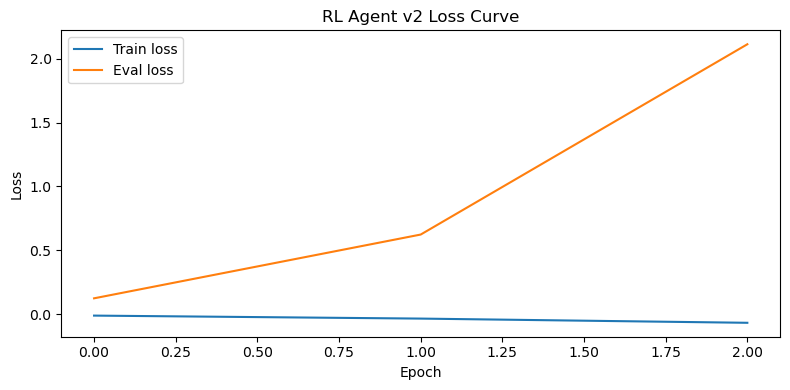

In [40]:
train_losses = []
eval_losses = []
best = 10
patience = 2
no_patience = 2
min_delta = 1e-3
max_delta = 1e-2

for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}\n------------------------------')
    t_loss = training_loop(train_loader, train_network, loss_fn, optimizer, target_network)
    train_losses.append(t_loss)

    final_preds, true_terminal, test_q_loss, full_preds = evaluation_loop(
        test_loader, target_network, loss_fn, train_network
    )
    eval_losses.append(test_q_loss)

    if test_q_loss < best:
        update_target_network()
        best = test_q_loss
    elif abs(test_q_loss - best) <= min_delta:
        patience -= 1
    elif abs(test_q_loss - best) >= max_delta:
        no_patience -= 1

    if not patience or not no_patience:
        break

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss')
ax.plot([l.item() if hasattr(l, 'item') else l for l in eval_losses], label='Eval loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('RL Agent v2 Loss Curve')
ax.legend(); plt.tight_layout(); plt.show()

# Agent Evaluation

Two evaluation lenses:

1. **Disposition accuracy** — F1 and recall at terminal timesteps. The agent's recommendation at the last timestep of each stay is compared to the provider's actual decision. ICU transfer is the positive class (higher-stakes prediction).

2. **Decision timing** — for stays where the agent makes a correct recommendation, how many steps earlier (or later) did it do so compared to the provider's terminal decision? Positive `steps_earlier` means the agent could have flagged the patient sooner.

In [21]:
print('Action mapping (name -> index):')
print(action_mapping)
print('\nAction reverse mapping (index -> name):')
print(action_reverse_mapping)
print('\nTerminal code mapping:')
print(terminal_code_mapping)

Action mapping (name -> index):
{'discharge': 0, 'transfer_icu': 1}

Action reverse mapping (index -> name):
{0: 'discharge', 1: 'transfer_icu'}

Terminal code mapping:
{0: 'discharge', 1: 'transfer_icu'}


In [41]:
# Attach model predictions to the full test dataframe (all timesteps)
df_test['preds'] = [p.item() for p in full_preds]

fp_vals, fp_counts = np.unique([p.item() for p in full_preds], return_counts=True)
at_vals, at_counts = np.unique(action_test.numpy(), return_counts=True)

print('Predicted action distribution (all timesteps):')
for v, c in zip(fp_vals, fp_counts):
    print(f'  {str(action_reverse_mapping.get(int(v), v)):<20}  {c:>6}  ({c/len(full_preds):.2%})')

print('\nTrue action distribution (all timesteps):')
for v, c in zip(at_vals, at_counts):
    print(f'  {str(action_reverse_mapping.get(int(v), v)):<20}  {c:>6}  ({c/len(action_test):.2%})')

Predicted action distribution (all timesteps):
  discharge              69335  (77.47%)
  transfer_icu           20164  (22.53%)

True action distribution (all timesteps):
  discharge              68690  (76.75%)
  transfer_icu           20809  (23.25%)


In [42]:
# Isolate predictions at terminal timesteps only
preds = np.asarray([p.item() for p in final_preds])
true = np.asarray([t.item() for t in true_terminal])

print('Terminal state - predicted action distribution:')
tp_vals, tp_counts = np.unique(preds, return_counts=True)
for v, c in zip(tp_vals, tp_counts):
    print(f'  {str(action_reverse_mapping.get(int(v), v)):<20}  {c:>6}  ({c/len(preds):.2%})')

Terminal state - predicted action distribution:
  discharge               5028  (74.63%)
  transfer_icu            1709  (25.37%)


In [43]:
# Convert action indices to disposition labels
new_preds = np.where(preds == action_mapping['discharge'], 'discharge', 'transfer_icu')
new_true = np.where(true == 0, 'discharge', 'transfer_icu')

np_vals, np_counts = np.unique(new_preds, return_counts=True)
nt_vals, nt_counts = np.unique(new_true, return_counts=True)

print('Predicted disposition:')
for v, c in zip(np_vals, np_counts):
    print(f'  {v:<15}  {c:>5}  ({c/len(new_preds):.2%})')

print('\nTrue disposition:')
for v, c in zip(nt_vals, nt_counts):
    print(f'  {v:<15}  {c:>5}  ({c/len(new_true):.2%})')

Predicted disposition:
  discharge         5028  (74.63%)
  transfer_icu      1709  (25.37%)

True disposition:
  discharge         5277  (78.33%)
  transfer_icu      1460  (21.67%)


F1 Score (transfer_icu):  0.6999
Recall   (transfer_icu):  0.7596


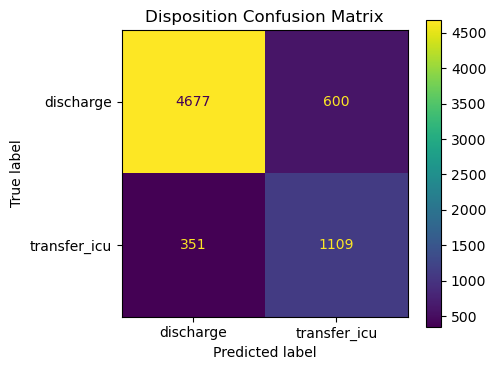

In [44]:
# Disposition classification metrics — positive class is transfer_icu
f1 = f1_score(new_true, new_preds, pos_label='transfer_icu')
recall = recall_score(new_true, new_preds, pos_label='transfer_icu')
print(f'F1 Score (transfer_icu):  {f1:.4f}')
print(f'Recall   (transfer_icu):  {recall:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    new_true, new_preds, ax=ax, display_labels=['discharge', 'transfer_icu']
)
ax.set_title('Disposition Confusion Matrix')
plt.tight_layout()
plt.show()

Stays where agent made a correct recommendation: 6,373

Steps earlier than provider (positive = earlier):
count    6373.000000
mean       11.519222
std         7.879416
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        75.000000
Name: steps_earlier, dtype: float64


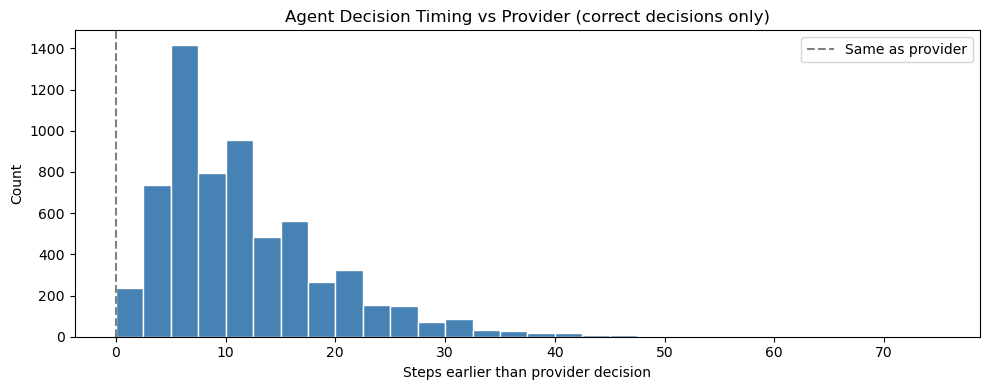


Performance by stay length (RL agent):
          bin    n  icu_rate  f1_icu  median_steps_earlier
Q1 (shortest) 2202     0.161  0.8626                   5.0
           Q2 1595     0.241  0.7387                   9.0
           Q3 1521     0.254  0.6552                  14.0
        18-29 1133     0.223  0.5814                  21.0
        30-54  279     0.290  0.5787                  32.0
          55+    7     0.143  0.0000                  63.0


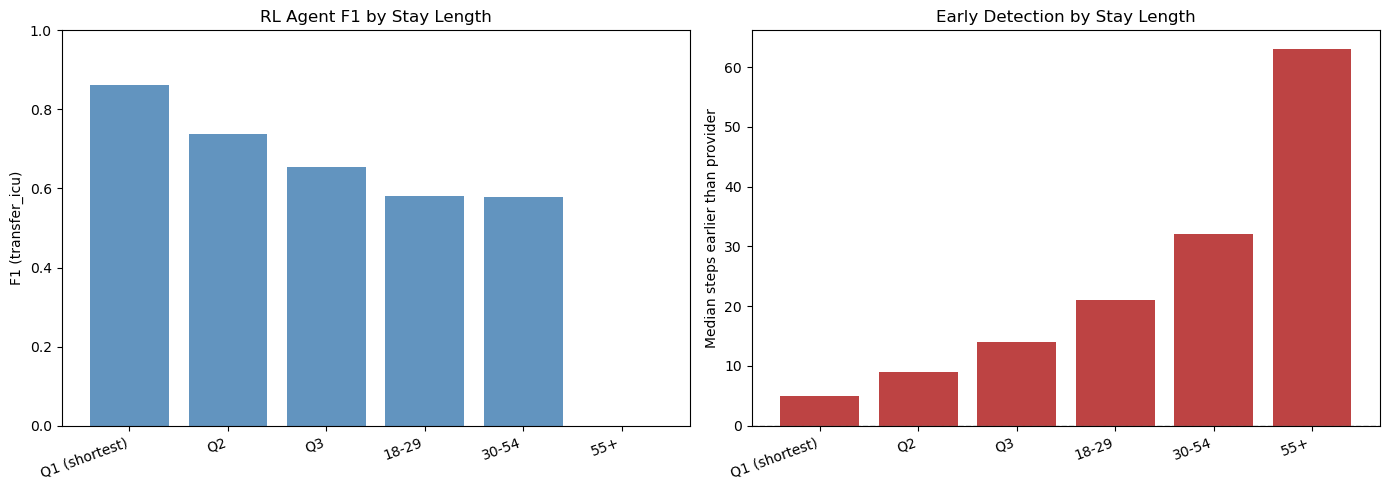

In [45]:
# Decision timing: when did the agent first make the correct recommendation
# compared to the provider's terminal decision?
# Positive steps_earlier = agent could have flagged the patient sooner

provider_steps = (
    df_test[df_test['terminal_state'] == 1][['ed_stay_id', 'time_steps']]
    .rename(columns={'time_steps': 'provider_step'})
)

# True disposition per stay (from terminal row)
true_disposition = (
    df_test[df_test['terminal_state'] == 1][['ed_stay_id', 'terminal_code']]
    .rename(columns={'terminal_code': 'true_code'})
)

df_test_ann = df_test.merge(true_disposition, on='ed_stay_id', how='left')

# First step where agent recommendation matches true outcome
agent_correct_first = (
    df_test_ann[df_test_ann['preds'] == df_test_ann['true_code']]
    .groupby('ed_stay_id')['time_steps']
    .min()
    .reset_index()
    .rename(columns={'time_steps': 'agent_step'})
)

timing_df = provider_steps.merge(agent_correct_first, on='ed_stay_id', how='inner')
timing_df['steps_earlier'] = timing_df['provider_step'] - timing_df['agent_step']

print(f'Stays where agent made a correct recommendation: {len(timing_df):,}')
print(f'\nSteps earlier than provider (positive = earlier):')
print(timing_df['steps_earlier'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(timing_df['steps_earlier'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, label='Same as provider')
ax.set_xlabel('Steps earlier than provider decision')
ax.set_ylabel('Count')
ax.set_title('Agent Decision Timing vs Provider (correct decisions only)')
ax.legend(); plt.tight_layout(); plt.show()

# Stay-length breakdown
# Match binning from LSTM evaluation for direct comparison.
# stay_length = provider_step (total hourly timesteps in the stay)

# Build per-stay results dataframe for breakdown
stay_results = (
    df_test[df_test['terminal_state'] == 1]
    [['ed_stay_id', 'terminal_code', 'time_steps', 'p_icu']]
    .copy()
    .rename(columns={'time_steps': 'los_steps', 'terminal_code': 'true_label'})
)
stay_results['pred_label'] = preds
stay_results['p_icu_terminal'] = stay_results['p_icu']

# Assign LOS bins — same thresholds as LSTM notebook
short_mask = stay_results['los_steps'] <= 17
long_mask  = stay_results['los_steps'] >= 18

stay_results['los_bin'] = None
stay_results.loc[short_mask, 'los_bin'] = pd.qcut(
    stay_results.loc[short_mask, 'los_steps'], q=3,
    labels=['Q1 (shortest)', 'Q2', 'Q3']
).astype(str)
stay_results.loc[long_mask & (stay_results['los_steps'] < 30),  'los_bin'] = '18-29'
stay_results.loc[long_mask & (stay_results['los_steps'].between(30, 54)), 'los_bin'] = '30-54'
stay_results.loc[stay_results['los_steps'] >= 55, 'los_bin'] = '55+'

bin_order = ['Q1 (shortest)', 'Q2', 'Q3', '18-29', '30-54', '55+']
stay_results['los_bin'] = pd.Categorical(stay_results['los_bin'],
                                          categories=bin_order, ordered=True)

# Add steps_earlier for stays with a correct recommendation
stay_results = stay_results.merge(
    timing_df[['ed_stay_id', 'steps_earlier']], on='ed_stay_id', how='left'
)

print('\nPerformance by stay length (RL agent):')
rows = []
for q, grp in stay_results.groupby('los_bin', observed=True):
    f1  = f1_score(grp['true_label'], grp['pred_label'],
                   pos_label=1, average='binary', zero_division=0)
    rec = grp.apply(lambda r: r['true_label'] == r['pred_label'] == 1, axis=1).sum()
    icu_n   = grp['true_label'].sum()
    icu_r   = grp['true_label'].mean()
    median_earlier = grp['steps_earlier'].median()
    rows.append({
        'bin':            q,
        'n':              len(grp),
        'icu_rate':       round(icu_r, 3),
        'f1_icu':         round(f1, 4),
        'median_steps_earlier': median_earlier,
    })

bin_df = pd.DataFrame(rows)
print(bin_df.to_string(index=False))

# Plot: F1 by stay length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(bin_df)), bin_df['f1_icu'], color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(bin_df)))
axes[0].set_xticklabels(bin_df['bin'], rotation=20, ha='right')
axes[0].set_ylabel('F1 (transfer_icu)')
axes[0].set_title('RL Agent F1 by Stay Length')
axes[0].set_ylim(0, 1)

axes[1].bar(range(len(bin_df)), bin_df['median_steps_earlier'].fillna(0),
            color='firebrick', alpha=0.85)
axes[1].set_xticks(range(len(bin_df)))
axes[1].set_xticklabels(bin_df['bin'], rotation=20, ha='right')
axes[1].set_ylabel('Median steps earlier than provider')
axes[1].set_title('Early Detection by Stay Length')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()